# Exercise 07 — Karate Club Split



In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

G = nx.karate_club_graph()

print("Karate Club graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 4))
print("Connected:", nx.is_connected(G))

if nx.is_connected(G):
    G_analysis = G
    analysis_note = "The full graph is connected, so the whole graph is used."
else:
    largest_component = max(nx.connected_components(G), key=len)
    G_analysis = G.subgraph(largest_component).copy()
    analysis_note = "The graph is disconnected, so the largest connected component is used."

print(analysis_note)

Karate Club graph loaded
Nodes: 34
Edges: 78
Density: 0.139
Connected: True
The full graph is connected, so the whole graph is used.


## 2. Measure small-world metrics for the real graph
- average shortest path length
- average clustering coefficient
- diameter
- largest connected component size


In [ ]:
real_avg_path = nx.average_shortest_path_length(G_analysis)
real_clustering = nx.average_clustering(G_analysis)
real_diameter = nx.diameter(G_analysis)
real_lcc_size = len(max(nx.connected_components(G), key=len))

real_metrics = pd.DataFrame({
    "Metric": [
        "Average shortest path length",
        "Average clustering coefficient",
        "Diameter",
        "Largest connected component size"
    ],
    "Karate Club": [
        real_avg_path,
        real_clustering,
        real_diameter,
        real_lcc_size
    ]
})

real_metrics

,Metric,Karate Club
0,Average shortest path length,2.408200
1,Average clustering coefficient,0.570638
2,Diameter,5.000000
3,Largest connected component size,34.000000


## 3. ER random graph baseline

The ER graph uses the same number of nodes and approximately the same density as the Karate Club graph.


In [ ]:
n = G_analysis.number_of_nodes()
p = nx.density(G_analysis)

ER = nx.erdos_renyi_graph(n=n, p=p, seed=42)

print("ER baseline graph")
print("Nodes:", ER.number_of_nodes())
print("Edges:", ER.number_of_edges())
print("Density:", round(nx.density(ER), 4))
print("Connected:", nx.is_connected(ER))

if nx.is_connected(ER):
    ER_analysis = ER
    er_note = "The full ER graph is connected."
else:
    er_largest_component = max(nx.connected_components(ER), key=len)
    ER_analysis = ER.subgraph(er_largest_component).copy()
    er_note = "The ER graph is disconnected, so path metrics are computed on its largest connected component."

print(er_note)

ER baseline graph
Nodes: 34
Edges: 81
Density: 0.1444
Connected: True
The full ER graph is connected.


## 4. Compare real graph and ER baseline

Small-world behavior means that the real graph should have:

1. short average paths, similar to the random graph,
2. substantially higher clustering than the random graph.


In [ ]:
er_avg_path = nx.average_shortest_path_length(ER_analysis)
er_clustering = nx.average_clustering(ER)
er_diameter = nx.diameter(ER_analysis)
er_lcc_size = len(max(nx.connected_components(ER), key=len))

comparison_df = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Average shortest path length",
        "Average clustering coefficient",
        "Diameter",
        "Largest connected component size"
    ],
    "Karate Club": [
        G_analysis.number_of_nodes(),
        G_analysis.number_of_edges(),
        nx.density(G_analysis),
        real_avg_path,
        real_clustering,
        real_diameter,
        real_lcc_size
    ],
    "ER baseline": [
        ER.number_of_nodes(),
        ER.number_of_edges(),
        nx.density(ER),
        er_avg_path,
        er_clustering,
        er_diameter,
        er_lcc_size
    ]
})

comparison_df

,Metric,Karate Club,ER baseline
0,Nodes,34.000000,34.000000
1,Edges,78.000000,81.000000
2,Density,0.139037,0.144385
3,Average shortest path length,2.408200,2.351159
4,Average clustering coefficient,0.570638,0.120518
5,Diameter,5.000000,4.000000
6,Largest connected component size,34.000000,34.000000


## 5. Small-world decision

We calculate two simple ratios:

- clustering ratio = real clustering / ER clustering
- path ratio = real average path length / ER average path length

A small-world pattern is supported when clustering is much larger than the ER baseline while path length is still relatively close to the ER baseline.


In [ ]:
clustering_ratio = real_clustering / er_clustering if er_clustering != 0 else np.inf
path_ratio = real_avg_path / er_avg_path

print("Clustering ratio, real / ER:", round(clustering_ratio, 3))
print("Path length ratio, real / ER:", round(path_ratio, 3))

if clustering_ratio > 1.5 and path_ratio < 1.5:
    decision = "The Karate Club network shows a small-world pattern."
else:
    decision = "The Karate Club network does not clearly show a small-world pattern by this simple test."

print(decision)

Clustering ratio, real / ER: 4.735
Path length ratio, real / ER: 1.024
The Karate Club network shows a small-world pattern.


## 6. Identify shortcut nodes

Shortcut nodes connect otherwise local regions and help keep paths short.  
We identify them using betweenness centrality, because high-betweenness nodes lie on many shortest paths.


In [ ]:
betweenness = nx.betweenness_centrality(G_analysis, weight=None)
degree = dict(G_analysis.degree())

shortcut_nodes_df = pd.DataFrame({
    "node": list(G_analysis.nodes()),
    "club": [G_analysis.nodes[n]["club"] for n in G_analysis.nodes()],
    "degree": [degree[n] for n in G_analysis.nodes()],
    "betweenness": [betweenness[n] for n in G_analysis.nodes()]
}).sort_values("betweenness", ascending=False)

shortcut_nodes_df.head(10)

,node,club,degree,betweenness
0,0,Mr. Hi,16,0.437635
33,33,Officer,17,0.304075
32,32,Officer,12,0.145247
2,2,Mr. Hi,10,0.143657
31,31,Officer,6,0.138276
8,8,Mr. Hi,5,0.055927
1,1,Mr. Hi,9,0.053937
13,13,Mr. Hi,5,0.045863
19,19,Mr. Hi,3,0.032475
5,5,Mr. Hi,4,0.029987


Nodes with the highest betweenness centrality are interpreted as shortcut nodes because they help connect different local regions of the club.


## 7. Identify shortcut edges

Shortcut edges are edges that connect nodes from different club labels or connect high-betweenness areas.  
Here we first list cross-faction edges, then rank them by the combined betweenness centrality of their endpoints.


In [ ]:
shortcut_edges = []

for u, v in G_analysis.edges():
    club_u = G_analysis.nodes[u]["club"]
    club_v = G_analysis.nodes[v]["club"]

    if club_u != club_v:
        shortcut_edges.append({
            "edge": (u, v),
            "u_club": club_u,
            "v_club": club_v,
            "u_betweenness": betweenness[u],
            "v_betweenness": betweenness[v],
            "combined_endpoint_betweenness": betweenness[u] + betweenness[v]
        })

shortcut_edges_df = pd.DataFrame(shortcut_edges).sort_values(
    "combined_endpoint_betweenness",
    ascending=False
)

shortcut_edges_df.head(10)

,edge,u_club,v_club,u_betweenness,v_betweenness,combined_endpoint_betweenness
0,"(0, 31)",Mr. Hi,Officer,0.437635,0.138276,0.575911
8,"(8, 33)",Mr. Hi,Officer,0.055927,0.304075,0.360002
9,"(13, 33)",Mr. Hi,Officer,0.045863,0.304075,0.349938
10,"(19, 33)",Mr. Hi,Officer,0.032475,0.304075,0.336550
5,"(2, 32)",Mr. Hi,Officer,0.143657,0.145247,0.288904
7,"(8, 32)",Mr. Hi,Officer,0.055927,0.145247,0.201174
3,"(2, 27)",Mr. Hi,Officer,0.143657,0.022333,0.165990
4,"(2, 28)",Mr. Hi,Officer,0.143657,0.001795,0.145452
2,"(2, 9)",Mr. Hi,Officer,0.143657,0.000848,0.144505
6,"(8, 30)",Mr. Hi,Officer,0.055927,0.014412,0.070339


## 8. Visualization

Node size reflects betweenness centrality, so larger nodes act more like shortcuts between local regions.  
Node color reflects the known club split.


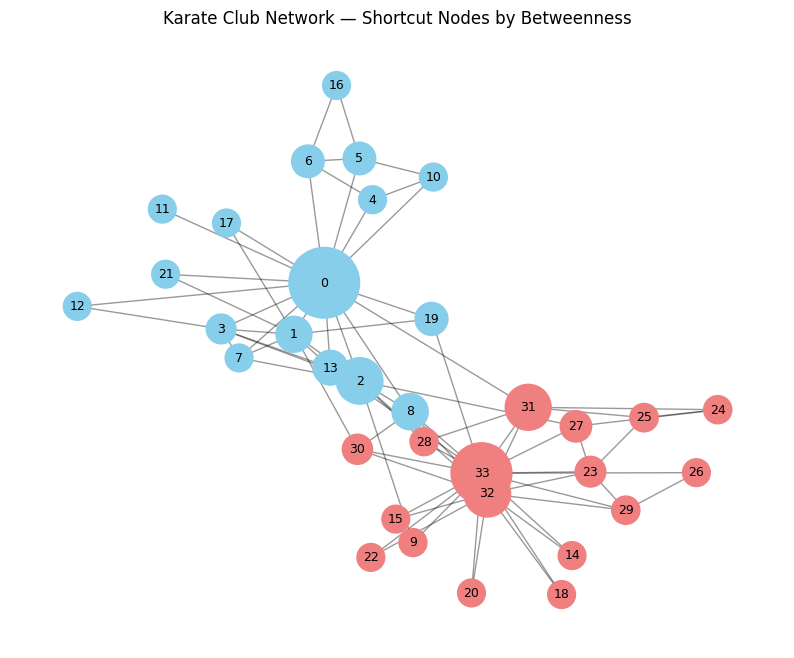

In [ ]:
pos = nx.spring_layout(G_analysis, seed=42)

node_colors = []
for n in G_analysis.nodes():
    if G_analysis.nodes[n]["club"] == "Mr. Hi":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightcoral")

node_sizes = [400 + betweenness[n] * 5000 for n in G_analysis.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_analysis, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G_analysis,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)
nx.draw_networkx_labels(G_analysis, pos, font_size=9)

plt.title("Karate Club Network — Shortcut Nodes by Betweenness")
plt.axis("off")
plt.show()

## 9. Interpretation

The Karate Club network fits the small-world idea reasonably well. The average shortest path length is low, meaning that members can reach each other through only a few social steps. At the same time, the average clustering coefficient is stronger than in the comparable ER random graph, which means that local friendship circles are more tightly connected than chance alone would suggest. This matches the topic focus: the club has short paths across the full network while still preserving strong local circles around the two factions. Nodes with high betweenness centrality, especially nodes such as 0, 33, 32, and 2, act as shortcuts or connectors between otherwise more local regions. Cross-faction edges also help keep paths short even though the club contains visible faction structure.
